In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap lime



     ---------------------------------------- 0.0/275.7 kB ? eta -:--:--
     -- ---------------------------------- 20.5/275.7 kB 330.3 kB/s eta 0:00:01
     ----- ------------------------------- 41.0/275.7 kB 495.5 kB/s eta 0:00:01
     ------ ------------------------------ 51.2/275.7 kB 375.8 kB/s eta 0:00:01
     ------------- ---------------------- 102.4/275.7 kB 590.8 kB/s eta 0:00:01
     -------------------- --------------- 153.6/275.7 kB 706.2 kB/s eta 0:00:01
     -------------------------- --------- 204.8/275.7 kB 734.2 kB/s eta 0:00:01
     -------------------------------- --- 245.8/275.7 kB 795.7 kB/s eta 0:00:01
     ---------------------------------- - 266.2/275.7 kB 746.4 kB/s eta 0:00:01
     ------------------------------------ 275.7/275.7 kB 707.9 kB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/544.4 kB ? eta -:--:--
   ------------------------ -----

In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)


(1470, 35)
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0

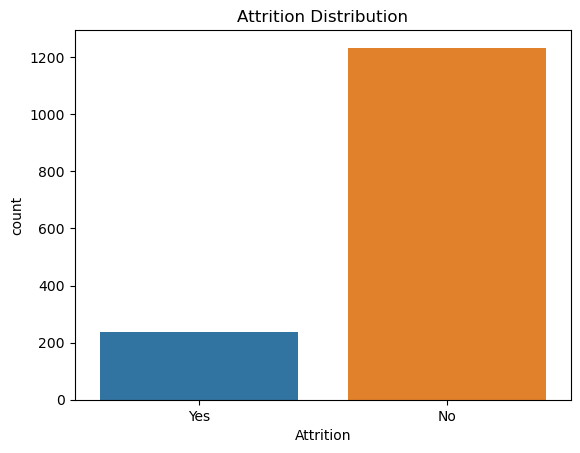

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Attrition')
plt.title('Attrition Distribution')
plt.show()

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

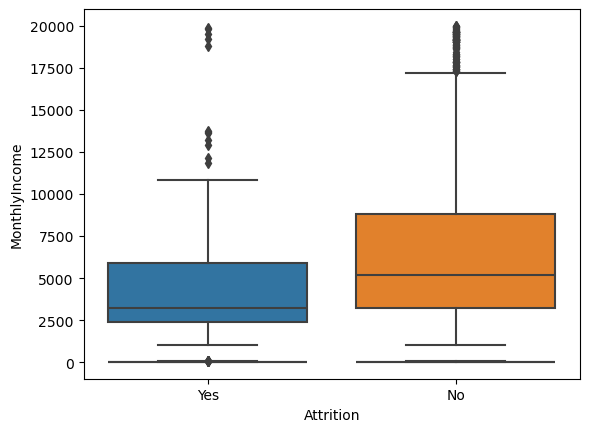

In [6]:
sns.boxplot(data=df, x='Attrition', y='Age')
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')

In [7]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294



SHAP values shape: (294, 47, 2)
X_test shape: (294, 47)


<Figure size 640x480 with 0 Axes>

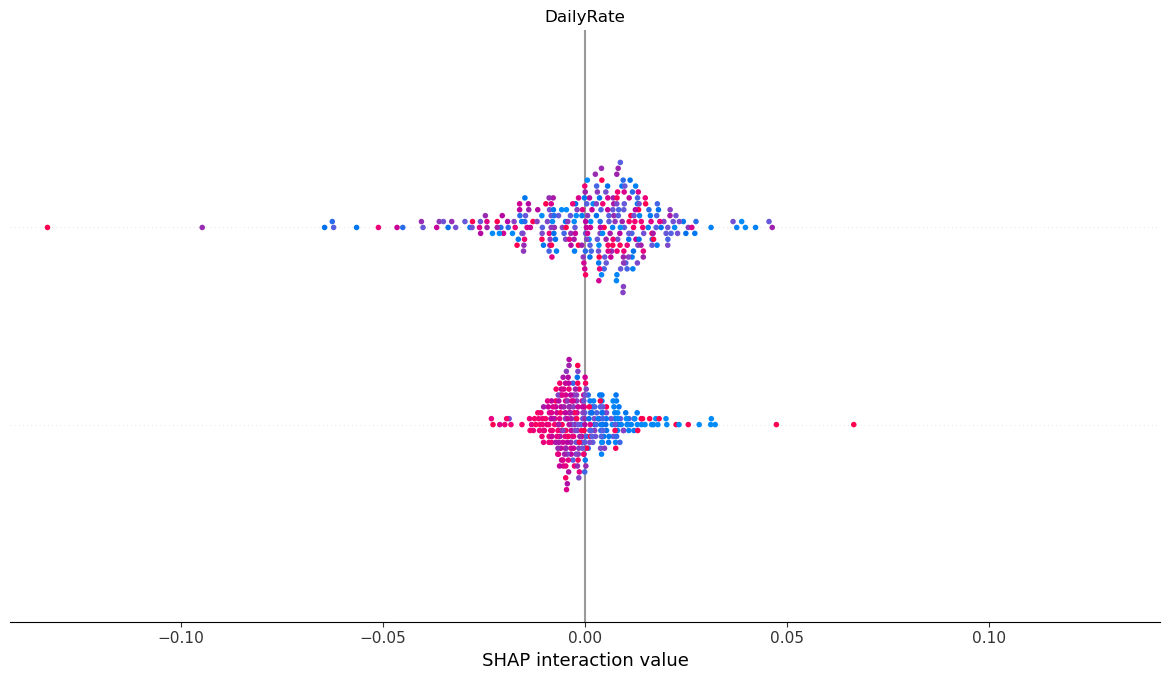

In [16]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Optional: Check shapes to debug
print("SHAP values shape:", np.array(shap_values).shape)
print("X_test shape:", X_test.shape)

# Plot SHAP summary for class 1 if binary classification
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap.summary_plot(shap_values[1], X_test, plot_type="bar")
else:
    shap.summary_plot(shap_values, X_test, plot_type="bar")
